#### Data Ingestion and EDA

##### Importing Libraries and Building Data

In [1]:
from os import rename

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [82]:
project_root = Path.cwd().parent
raw_dir = project_root/'data'/'raw'
processed_dir = project_root/'data'/'processed'
fig_dir = project_root/'reports'/'figures'

In [3]:
# Station Entries Data

mon_entries = pd.read_excel(raw_dir/'NBT24MON_outputs.xlsx', sheet_name='Station_Entries', skiprows=2)
twt_entries = pd.read_excel(raw_dir/'NBT24TWT_outputs.xlsx', sheet_name='Station_Entries', skiprows=2)
fri_entries = pd.read_excel(raw_dir/'NBT24FRI_outputs.xlsx', sheet_name='Station_Entries', skiprows=2)
sat_entries = pd.read_excel(raw_dir/'NBT24SAT_outputs.xlsx', sheet_name='Station_Entries', skiprows=2)
sun_entries = pd.read_excel(raw_dir/'NBT24SUN_outputs.xlsx', sheet_name='Station_Entries', skiprows=2)

In [4]:
# Station Exits Data

mon_exits = pd.read_excel(raw_dir/'NBT24MON_outputs.xlsx', sheet_name='Station_Exits', skiprows=2)
twt_exits = pd.read_excel(raw_dir/'NBT24TWT_outputs.xlsx', sheet_name='Station_Exits', skiprows=2)
fri_exits = pd.read_excel(raw_dir/'NBT24FRI_outputs.xlsx', sheet_name='Station_Exits', skiprows=2)
sat_exits = pd.read_excel(raw_dir/'NBT24SAT_outputs.xlsx', sheet_name='Station_Exits', skiprows=2)
sun_exits = pd.read_excel(raw_dir/'NBT24SUN_outputs.xlsx', sheet_name='Station_Exits', skiprows=2)

In [5]:
# Adding Day Type Column and Concatenating

mon_entries['daytype'] = 'mon'
twt_entries['daytype'] = 'twt'
fri_entries['daytype'] = 'fri'
sat_entries['daytype'] = 'sat'
sun_entries['daytype'] = 'sun'

mon_exits['daytype'] = 'mon'
twt_exits['daytype'] = 'twt'
fri_exits['daytype'] = 'fri'
sat_exits['daytype'] = 'sat'
sun_exits['daytype'] = 'sun'

entries = pd.concat([mon_entries, twt_entries, fri_entries, sat_entries, sun_entries], ignore_index=True)
exits   = pd.concat([mon_exits,   twt_exits,   fri_exits,   sat_exits,   sun_exits],   ignore_index=True)

C:\Users\Abdul Qudus\AppData\Local\Temp\ipykernel_67504\1447135668.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mon_entries['daytype'] = 'mon'
C:\Users\Abdul Qudus\AppData\Local\Temp\ipykernel_67504\1447135668.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  twt_entries['daytype'] = 'twt'
C:\Users\Abdul Qudus\AppData\Local\Temp\ipykernel_67504\1447135668.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joini

In [6]:
entries.head()

,NLC,ASC,Station,Fare Zone,Total,Early,AM Peak,Midday,PM Peak,Evening,...,0245-0300,0300-0315,0315-0330,0330-0345,0345-0400,0400-0415,0415-0430,0430-0445,0445-0500,daytype
0,750,ABRd,Abbey Road,2/3,2213.075128,162.776450,571.665843,686.594545,484.034660,210.685589,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,mon
1,1404,ACCr,Acton Central,3,2614.926496,211.235159,794.874640,695.597180,626.410415,214.559705,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,mon
2,3000,AMLr,Acton Main Line,3,5053.778063,391.802599,1877.090299,1405.782117,1049.736629,266.382704,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,mon
3,500,ACTu,Acton Town,3,7361.581122,433.918092,2477.618002,2246.089663,1589.066111,450.465788,...,0.0,0.0,0.0,0.0,0.0,0.0,4.817381,4.817381,4.817381,mon
4,9441,ADVt,Addington Village,4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,mon


In [7]:
exits.head()

,NLC,ASC,Station,Fare Zone,Total,Early,AM Peak,Midday,PM Peak,Evening,...,0245-0300,0300-0315,0315-0330,0330-0345,0345-0400,0400-0415,0415-0430,0430-0445,0445-0500,daytype
0,750,ABRd,Abbey Road,2/3,2053.850287,68.310194,419.016967,535.340780,548.150298,254.774118,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,mon
1,1404,ACCr,Acton Central,3,2495.887782,47.580602,651.133276,586.758100,822.029726,274.183377,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,mon
2,3000,AMLr,Acton Main Line,3,4760.744787,162.184171,806.045766,916.979372,1613.937958,940.481084,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,mon
3,500,ACTu,Acton Town,3,7466.429127,325.680040,1521.583729,1585.880503,2217.150779,1239.241658,...,0.0,0.0,0.0,0.0,0.0,0.0,1.381897e-07,1.381897e-07,1.381897e-07,mon
4,9441,ADVt,Addington Village,4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,mon


In [8]:
entries.shape, exits.shape

((2355, 108), (2355, 108))

In [12]:
# Quarter Hour Columns

qcols = [c for c in entries.columns if isinstance(c, str) and len(c) == 9 and '-' in c]

In [15]:
# Melting entries and exits and stacking in a single long DataFrame

entries_long = entries.melt(
    id_vars=['NLC', 'daytype'],
    value_vars=qcols,
    var_name='quarter_hour',
    value_name='count'
)
entries_long['metric'] = 'entries'

exits_long = exits.melt(
    id_vars=['NLC', 'daytype'],
    value_vars=qcols,
    var_name='quarter_hour',
    value_name='count'
)
exits_long['metric'] = 'exits'

In [16]:
long = pd.concat([entries_long, exits_long], ignore_index=True)

In [17]:
long.head()

,NLC,daytype,quarter_hour,count,metric
0,750,mon,0500-0515,4.273800,entries
1,1404,mon,0500-0515,0.000000,entries
2,3000,mon,0500-0515,7.703675,entries
3,500,mon,0500-0515,7.657625,entries
4,9441,mon,0500-0515,0.000000,entries


In [18]:
long = long.rename(columns={'NLC': 'nlc'})

In [19]:
long.shape

(452160, 5)

In [20]:
# Checking Ghost stations: Stations with no traffic

total_entries_per_station = (
    long[long['metric'] == 'entries']
    .groupby('nlc')['count']
    .sum()
)

In [24]:
ghost_nlc = total_entries_per_station[total_entries_per_station == 0].index

In [30]:
print ('Number of Ghost Stations:', len(ghost_nlc))

Number of Ghost Stations: 39


In [36]:
ghost_names = entries[entries['NLC'].isin(ghost_nlc)]['Station'].unique()

In [46]:
ghost_names

<ArrowStringArray>
[       'Addington Village',               'Addiscombe',
               'Ampere Way',                    'Arena',
              'Avenue Road', 'Beckenham Junction Trams',
           'Beckenham Road',          'Beddington Lane',
            'Belgrave Walk',           'Birkbeck Trams',
          'Blackhorse Lane',                 'Centrale',
            'Church Street',              'Coombe Lane',
           'Dundonald Road',       'East Croydon Trams',
               'Elmers End',                 'Fieldway',
            'George Street',              'Gravel Hill',
          'Harrington Road',       'King Henry's Drive',
             'Lebanon Road',               'Lloyd Park',
              'Merton Park',                  'Mitcham',
         'Mitcham Junction',              'Morden Road',
            'New Addington',            'Phipps Bridge',
            'Reeves Corner',               'Sandilands',
            'Therapia Lane',             'Waddon Marsh',
            

In [47]:
# Creating Station Dimension Table

station_dim = (
    entries.drop_duplicates('NLC')[['NLC', 'ASC', 'Station', 'Fare Zone']]
    .rename(columns={
        'NLC': 'nlc',
        'ASC': 'asc',
        'Station': 'station_name',
        'Fare Zone': 'fare_zone'}
            ).reset_index(drop=True)
)

In [49]:
station_dim.head()

,nlc,asc,station_name,fare_zone
0,750,ABRd,Abbey Road,2/3
1,1404,ACCr,Acton Central,3
2,3000,AMLr,Acton Main Line,3
3,500,ACTu,Acton Town,3
4,9441,ADVt,Addington Village,4


In [51]:
station_dim['active'] = ~station_dim['nlc'].isin(ghost_nlc)

In [52]:
station_dim.head()

,nlc,asc,station_name,fare_zone,active
0,750,ABRd,Abbey Road,2/3,True
1,1404,ACCr,Acton Central,3,True
2,3000,AMLr,Acton Main Line,3,True
3,500,ACTu,Acton Town,3,True
4,9441,ADVt,Addington Village,4,False


In [58]:
station_dim['fare_zone'] = station_dim['fare_zone'].astype(str)

In [59]:
station_dim.shape

(471, 5)

In [60]:
# Saving Data

long.to_parquet(processed_dir/'station_time.parquet', index=False)
station_dim.to_parquet(processed_dir/'station_dimension.parquet', index=False)

In [65]:
active_nlc = station_dim[station_dim['active']]['nlc']

In [69]:
# Network demand by Day Type

demand_daytype = (
    long[(long['metric'] == 'entries') & (long['nlc'].isin(active_nlc))]
    .groupby('daytype')['count']
    .sum()
    .reindex(['mon', 'twt', 'fri', 'sat', 'sun'])
)

In [70]:
demand_daytype

daytype
mon    4.404409e+06
twt    5.169048e+06
fri    4.747508e+06
sat    4.237401e+06
sun    2.828100e+06
Name: count, dtype: float64

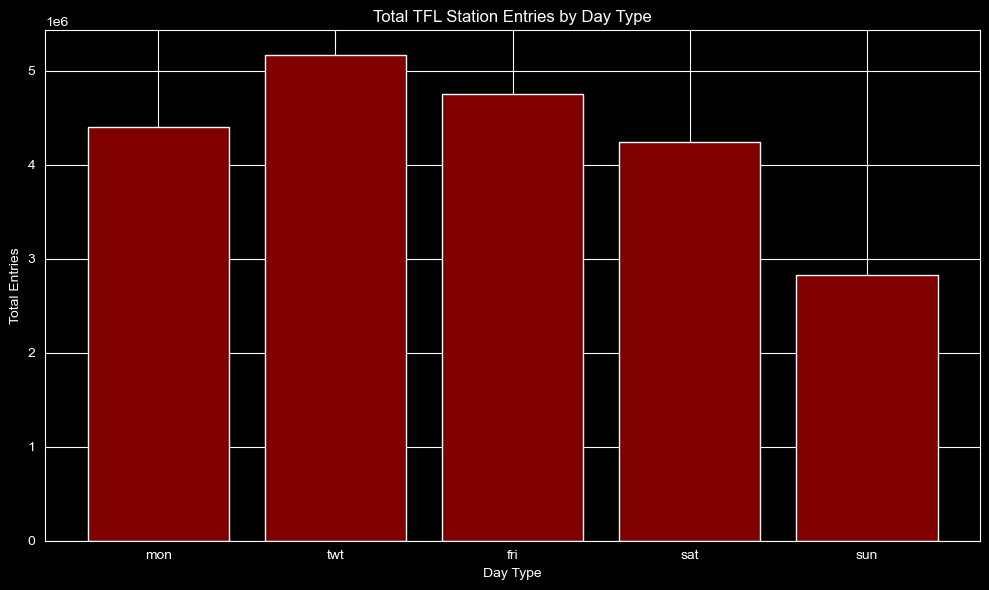

<Figure size 640x480 with 0 Axes>

In [84]:
plt.figure(figsize=[10, 6])
plt.bar(demand_daytype.index, demand_daytype.values, color='maroon')
plt.xlabel('Day Type')
plt.ylabel('Total Entries')
plt.title('Total TFL Station Entries by Day Type')

plt.tight_layout()
plt.show()

plt.savefig(fig_dir/'demand_daytype.png', dpi=120, bbox_inches='tight')